# [Kaggle] Task 1: Aspect Term Extraction (ATE)
## Baselines: TextCNN-CRF, RNN-CRF, LSTM-CRF, GRU-CRF, BiLSTM-CRF, BiGRU-CRF

Add 2 datasets: `absa-data` (jsonl files) + `absa-src` (source code)


## 0. Setup


In [1]:
import subprocess, sys, os

# Install dependencies
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'underthesea', 'pytorch-crf', 'gensim'])

# =====================================================
# THAY DOI TEN DATASET DUOI DAY CHO DUNG
# =====================================================
DATA_DATASET = "UIT-ViSD4SA"      # Dataset chua train/dev/test.jsonl
SRC_DATASET  = "absa-src"       # Dataset chua folder src/

IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    DATA_DIR = '/kaggle/input/datasets/danghoang1302/uit-visd4sa'
    SAVE_DIR = '/kaggle/working/results'
    PREP_DIR = '/kaggle/working/preprocessed'

    # Kaggle mount: /kaggle/input/absa-src/src/{asc,ate,e2e,utils}
    # Copy sang working vi Kaggle input la read-only (relative imports can write cache)
    SRC_INPUT = '/kaggle/input/datasets/danghoang1302/absa-src'
    os.system(f'cp -r {SRC_INPUT}/src /kaggle/working/src')
    sys.path.insert(0, '/kaggle/working')

    print(f"KAGGLE | Data: {DATA_DIR}")
    print(f"KAGGLE | Src copied to: /kaggle/working/src/")
else:
    sys.path.insert(0, os.path.abspath(".."))
    DATA_DIR = os.path.join("..", "..", "data")
    SAVE_DIR = os.path.join("..", "..", "results")
    PREP_DIR = os.path.join("..", "..", "preprocessed")
    print(f"LOCAL mode")

# Verify
for fn in ['train.jsonl', 'dev.jsonl', 'test.jsonl']:
    assert os.path.exists(os.path.join(DATA_DIR, fn)), f"MISSING: {fn}"
print("All data files OK!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.9 MB/s eta 0:00:00
KAGGLE | Data: /kaggle/input/datasets/danghoang1302/uit-visd4sa
KAGGLE | Src copied to: /kaggle/working/src/
All data files OK!


## 1. Imports


In [2]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from IPython.display import display

from src.utils.preprocess import (
    load_raw_data, segment_items, build_vocab,
    train_w2v_embeddings, save_preprocessed
)
from src.ate.ate_dataset import ATEDataset, BIO_TAGS, NUM_TAGS
from src.ate.ate_model import build_ate_model
from src.utils.engine import train_ate_model, predict_ate
from src.utils.metrics import bio_tags_to_spans, evaluate_spans_f1, token_accuracy
from src.utils.visualization import plot_training_curves, plot_model_comparison

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print(f"Device: {device}")
if device.type == 'cuda': print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


## 2. Load Data & Build Embeddings


In [3]:
train_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "train.jsonl")))
dev_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "dev.jsonl")))
test_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "test.jsonl")))
print(f"Train: {len(train_items)} | Dev: {len(dev_items)} | Test: {len(test_items)}")

all_texts = [item["text"] for item in train_items + dev_items + test_items]
word2idx = build_vocab(all_texts, min_freq=2, special_tokens=["[ASP]"])
VOCAB_SIZE = len(word2idx)
EMB_DIM = 150
emb_matrix = train_w2v_embeddings(all_texts, word2idx, emb_dim=EMB_DIM)

# Save cho NB02, NB03
save_preprocessed(PREP_DIR, word2idx, emb_matrix, train_items, dev_items, test_items)


Train: 7785 | Dev: 1112 | Test: 2225
Training Word2Vec 150d...
Embedding Matrix ready. Hit: 6166/6169 (100.0%)
Saved preprocessed data to /kaggle/working/preprocessed/
  - word2idx: 6169 tokens
  - emb_matrix: (6169, 150)
  - train/dev/test: 7785/1112/2225


## 3. DataLoaders


In [4]:
MAX_LEN = 128; HIDDEN_DIM = 256; NUM_LAYERS = 2; DROPOUT = 0.3
BATCH_SIZE = 64; EPOCHS = 30; PATIENCE = 7

train_ds = ATEDataset(train_items, word2idx, MAX_LEN)
dev_ds = ATEDataset(dev_items, word2idx, MAX_LEN)
test_ds = ATEDataset(test_items, word2idx, MAX_LEN)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_ds, BATCH_SIZE)
test_loader = DataLoader(test_ds, BATCH_SIZE)
print(f"Ready! Train: {len(train_ds)} | Dev: {len(dev_ds)} | Test: {len(test_ds)}")


Ready! Train: 7785 | Dev: 1112 | Test: 2225


## 4. Train All Baselines


In [5]:
MODEL_TYPES = ["TextCNN", "RNN", "LSTM", "GRU", "BiLSTM", "BiGRU"]
all_models, all_histories = {}, {}

for mt in MODEL_TYPES:
    model = build_ate_model(
        model_type=mt, vocab_size=VOCAB_SIZE, emb_dim=EMB_DIM,
        hidden_dim=HIDDEN_DIM, num_tags=NUM_TAGS,
        pretrained_emb=emb_matrix, n_layers=NUM_LAYERS, dropout=DROPOUT,
    ).to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{mt}-CRF | Params: {params:,}")
    model, history = train_ate_model(
        model, train_loader, dev_loader, device,
        lr=1e-3, epochs=EPOCHS, patience=PATIENCE, model_name=f"{mt}-CRF"
    )
    all_models[mt] = model; all_histories[mt] = history


TextCNN-CRF | Params: 1,805,982

  Training TextCNN-CRF


Training:   0%|          | 0/122 [00:00<?, ?it/s]

  Ep  1/30 | Train Loss: 55.8744 | Dev Loss: 40.9364 | TokAcc: 0.6145 | LR: 0.001000 | 20.6s ***


Training:   0%|          | 0/122 [00:00<?, ?it/s]

  Ep  2/30 | Train Loss: 38.8982 | Dev Loss: 34.6356 | TokAcc: 0.6426 | LR: 0.001000 | 18.6s ***


...

  Ep 20/30 | Train Loss: 5.8439 | Dev Loss: 18.7742 | TokAcc: 0.7038 | LR: 0.000500 | 20.5s


Training:   0%|          | 0/122 [00:00<?, ?it/s]

  Ep 21/30 | Train Loss: 5.6369 | Dev Loss: 18.9933 | TokAcc: 0.7016 | LR: 0.000500 | 20.3s


Training:   0%|          | 0/122 [00:00<?, ?it/s]

  Ep 22/30 | Train Loss: 5.2380 | Dev Loss: 19.6609 | TokAcc: 0.7032 | LR: 0.000250 | 20.3s
  Early stopping at epoch 22


## 5. Test Evaluation


In [6]:
all_results = []
for mt, model in all_models.items():
    test_res = predict_ate(model, test_loader, device)
    pred_spans = [bio_tags_to_spans(pt, BIO_TAGS, l) for pt, l in zip(test_res["pred_tags"], test_res["lengths"])]
    true_spans = [bio_tags_to_spans(tt, BIO_TAGS, l) for tt, l in zip(test_res["true_tags"], test_res["lengths"])]
    sf = evaluate_spans_f1(pred_spans, true_spans)
    ta = token_accuracy(test_res["pred_tags"], test_res["true_tags"])
    all_results.append({"Model": f"{mt}-CRF", "Span_P": round(sf["precision"],4),
                         "Span_R": round(sf["recall"],4), "Span_F1": round(sf["f1"],4), "Token_Acc": round(ta,4)})

results_df = pd.DataFrame(all_results)
display(results_df.sort_values("Span_F1", ascending=False).style.highlight_max(subset=["Span_F1"], color="lightgreen"))


,Model,Span_P,Span_R,Span_F1,Token_Acc
5,BiGRU-CRF,0.397000,0.364300,0.379900,0.712200
4,BiLSTM-CRF,0.392100,0.335800,0.361800,0.710200
3,GRU-CRF,0.383600,0.312900,0.344700,0.681400
2,LSTM-CRF,0.364700,0.303500,0.331300,0.678400
1,RNN-CRF,0.362800,0.302700,0.330100,0.673500
0,TextCNN-CRF,0.281300,0.267400,0.274200,0.680000


## 6. Visualization & Save


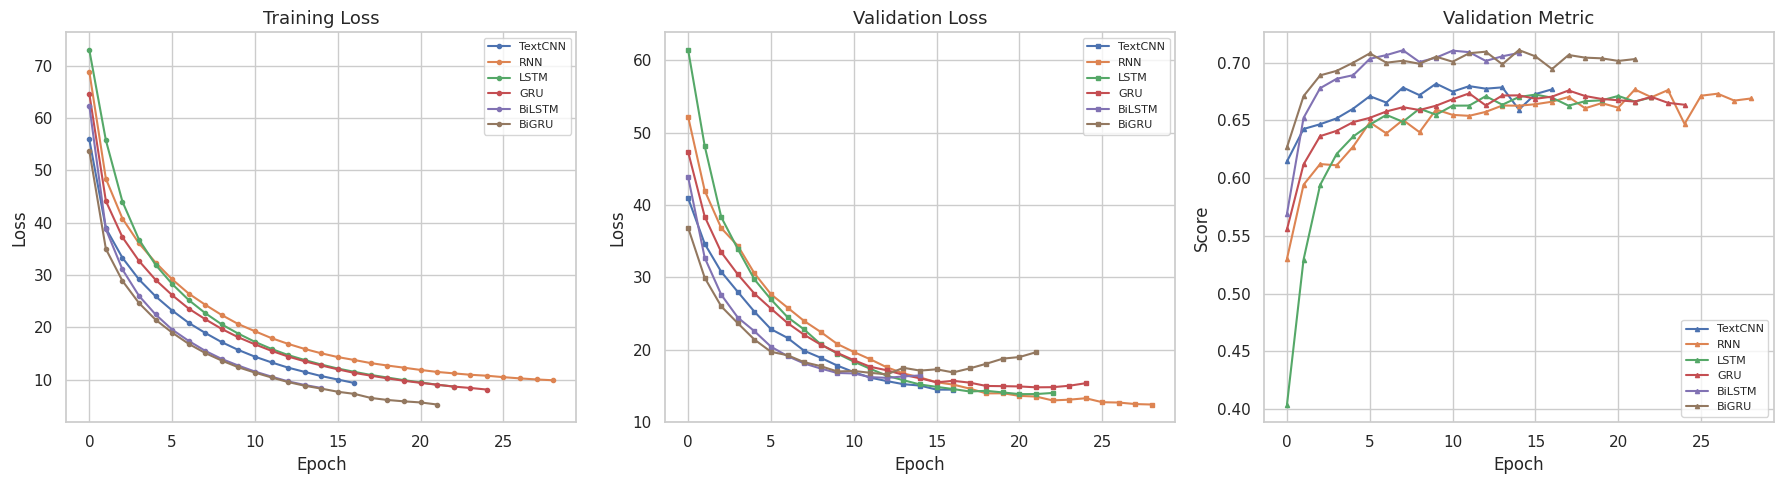

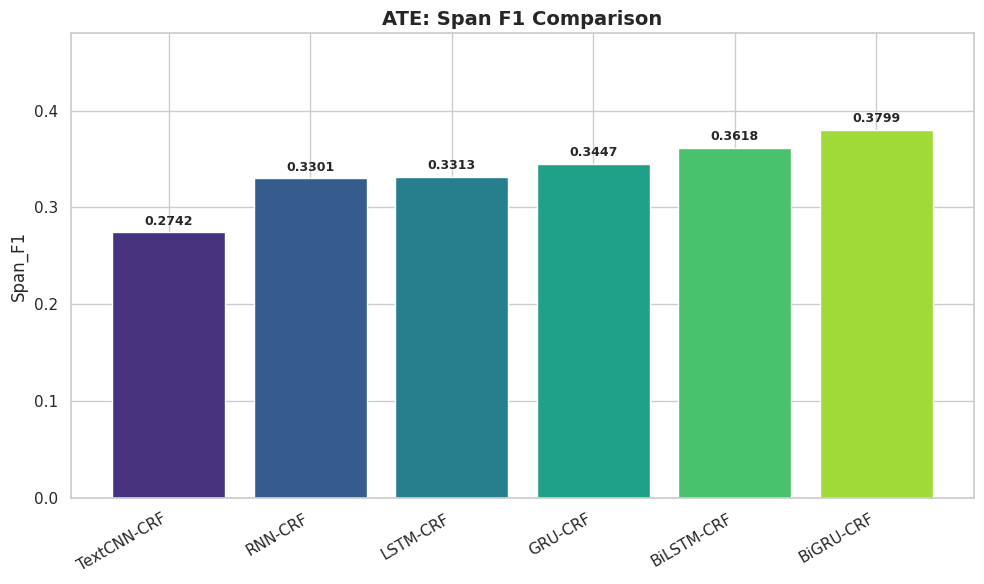

Best: BiGRU-CRF (F1=0.3799) -> Saved!


In [7]:
plot_training_curves(all_histories)
plot_model_comparison(results_df, metric_col="Span_F1", title="ATE: Span F1 Comparison")

ATE_DIR = os.path.join(SAVE_DIR, "ate"); os.makedirs(ATE_DIR, exist_ok=True)
results_df.to_csv(os.path.join(ATE_DIR, "ate_results.csv"), index=False)
best_name = results_df.loc[results_df["Span_F1"].idxmax(), "Model"]
best_key = best_name.replace("-CRF", "")
torch.save(all_models[best_key].state_dict(), os.path.join(ATE_DIR, f"best_ate_{best_name}.pt"))
print(f"Best: {best_name} (F1={results_df['Span_F1'].max():.4f}) -> Saved!")
